# Checking the difference in the number of candidates from $B^0$ 

https://raw.githubusercontent.com/bcouturi/phys/main/Category_19.png

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import uproot
from numba import jit
%matplotlib inline 

## Loading the file

In [2]:
datatype = "2012"
eventtype = "23903000"
polarity = "magdown"
sign = "rs"

In [3]:
def get_tree(datatype, eventtype, polarity, sign):
    #data_prefix = "root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/"
    data_prefix = "root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/"

    filename =  data_prefix + f"rds_categ_{datatype}_{eventtype}_{polarity}_{sign}.root"
    print(f"Loading DecayTree from {filename}")
    dt = uproot.open(filename + ":DecayTree")
    return dt

In [22]:
def create_df(dt):
    # Extracols
    extracols = ["B_M", "category",  "log(Y_PE)",  "min_m2pi", "max_m2pi", "missing_pY_mass", "Y_correctedMass" ]
    
    # Extracting the ancestry information
    arrs = dt.arrays( extracols + ["p1_fromY_PANC_IDs", "p2_fromY_PANC_IDs", "p3_fromY_PANC_IDs"])
    res = {}

    @jit(nopython=True) 
    def pprint(a):
        return ":".join([ str(int(p)) for p in a if p != 0])

    @jit(nopython=True) 
    def top_decay(a):
        return ":".join([ str(abs(int(p))) for p in a if p != 0 and abs(p) >= 500])

    @jit(nopython=True) 
    def dp_parent(l):
        al = [ abs(p) for p in l ]
        if 411 in al:
            i = al.index(411)
            return l[i+1]
        else:
            return 0
        
    for i in range(1,4):
        tmp = arrs[f"p{i}_fromY_PANC_IDs"]
        res[f"p{i}_fromY_DECAY"] = [ pprint(p) for p in tmp ]
        res[f"p{i}_fromY_TOP"] = [ top_decay(p) for p in tmp ]
        res[f"p{i}_fromY_Dp_PARENT"] = [ dp_parent(p) for p in tmp ]
    for c in extracols:
        res[c] = arrs[c]
    df = pd.DataFrame(res)
    return df

In [23]:
# l = [ 3, 4, 511, 34 ]
# def dp_parent(l):
    
# dp_parent(l)
    

In [24]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

## Loading the data for event type 23903000

In [25]:
dt = get_tree(datatype, eventtype, polarity, sign)
df23903000 = create_df(dt)

Loading DecayTree from root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/rds_categ_2012_23903000_magdown_rs.root


In [26]:
df23903000

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass
0,211:20213:411:511:513:-5,20213:511:513,511.0,-211:113:20213:411:511:513:-5,20213:511:513,511.0,211:113:20213:411:511:513:-5,20213:511:513,511.0,3549.868167,0,10.883605,323.821754,738.515145,565.022985,1224.106441
1,-211:-411:511:513:-5,511:513,511.0,321:-411:511:513:-5,511:513,511.0,-211:-411:511:513:-5,511:513,511.0,4290.554743,19,11.387159,981.135871,1117.291204,-18.277289,1780.966855
2,-211:331:-431:-433:-531:-533:5,531:533,0.0,211:221:331:-431:-433:-531:-533:5,531:533,0.0,11:-431:-433:-531:-533:5,531:533,0.0,3245.222951,18,9.402181,330.926390,404.550889,1032.144691,680.134493
3,211:223:421:423:-521:-10521:5,521:10521,0.0,-211:223:421:423:-521:-10521:5,521:10521,0.0,-11:111:223:421:423:-521:-10521:5,521:10521,0.0,3319.233948,0,9.734375,314.638899,511.873870,950.038948,933.400223
4,-211:10313:-411:-511:-513:5,10313:511:513,-511.0,211:10313:-411:-511:-513:5,10313:511:513,-511.0,13:-411:-511:-513:5,511:513,-511.0,3952.608126,19,11.047794,549.541128,584.769666,615.633365,1261.471478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152847,-211:223:-431:-433:-531:-533:5,531:533,0.0,211:223:-431:-433:-531:-533:5,531:533,0.0,-211:-431:-433:-531:-533:5,531:533,0.0,3771.552068,18,11.449902,341.207331,670.149991,688.894074,1129.770956
152848,,,0.0,211:223:-431:-433:-531:-533:5,531:533,0.0,-211:-431:-433:-531:-533:5,531:533,0.0,3992.818303,7,11.679653,423.336338,670.149991,379.840907,1553.556300
152849,-211:313:-431:-433:-531:-533:5,531:533,0.0,321:313:-431:-433:-531:-533:5,531:533,0.0,-211:-323:-431:-433:-531:-533:5,531:533,0.0,3794.304152,18,11.565948,664.236217,735.527257,660.204550,1216.412924
152850,211:413:-511:-513:5,511:513,0.0,-321:421:413:-511:-513:5,511:513,0.0,211:421:413:-511:-513:5,511:513,0.0,4944.666419,16,11.842987,565.155086,1788.457153,-102.158398,2140.537223


In [27]:
g23903000_hb = mygroupby(df23903000[df23903000.B_M > 4800 ], [ 'category', 'p1_fromY_TOP'])
g23903000_lb = mygroupby(df23903000[df23903000.B_M < 4800 ], [ 'category', 'p1_fromY_TOP'])

## Loading the data for event type 23903003

In [28]:
dt23903003 = get_tree(datatype, "23903003", polarity, sign)
df23903003 = create_df(dt23903003)

Loading DecayTree from root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/rds_categ_2012_23903003_magdown_rs.root


In [29]:
g23903003_hb = mygroupby(df23903003[df23903003.B_M > 4800 ], [ 'category', 'p1_fromY_TOP'])
g23903003_lb = mygroupby(df23903003[df23903003.B_M < 4800 ], [ 'category', 'p1_fromY_TOP'])

## Display repartitions

In [30]:
limit = 4800.0
df23903000['HIGH_B_M'] = df23903000.B_M > limit 
mygroupby(df23903000, 'HIGH_B_M')

,HIGH_B_M,count,Percentage,cumulative %
0,False,139313,91.142412,91.142412
1,True,13539,8.857588,100.000000


In [31]:
df23903003['HIGH_B_M'] = df23903003.B_M > limit 
mygroupby(df23903003, 'HIGH_B_M')

,HIGH_B_M,count,Percentage,cumulative %
0,False,160015,93.79103,93.79103
1,True,10593,6.20897,100.00000


In [32]:
def plot_for_category(categ, density=True, nbins=100):
    plt.hist(df23903003[df23903003.category==categ].B_M, bins=nbins, histtype='step', label='23903003', density=density)
    plt.hist(df23903000[df23903000.category==categ].B_M, bins=nbins, histtype='step', label='23903000', density=density)
    plt.axvline(x =4800, color = 'g', label = f'{limit} MeV')
    plt.legend()
    plt.title(f"B_M for category {categ}")


Catgories and their count for 23903000 (only categories with more than 100 candidates)

  - Xc_signal_Ypis_displaced_fromBs_fromDs 18	4338 ==> Ok
  - Xc_signal_Ypis_displaced_fromB0_fromDp 19	3184 ==> Differ
  - Xc_background                          0	1275 ==> Differ
  - Xc_signal_Ypis_diffVertex_CharmStrange 16	977 ==> Differ
  - Xc_signal_Ypis_nomatch_doubleCharm     7	831 ==> Ok
  - Xc_signal_Ypis_displaced_fromLambdab_fromLambdac 21	548 ==> Differ, only in Incl B
  - Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB	484 ==> Ok
  - Xc_signal_Ypis_B_vertex_fromBs         2	393 ==> Differ, Only in Incl B
  - Xc_signal_Ypis_displaced_fromBp_fromD0 20	357 ==> Ok
  - Xc_signal_Ypis_nomatch_charmStrange    8	281 ==> Differ
  - Xc_signal_Ypis_B_vertex_fromBs         1	253 ==> Ok
  - Xc_signal_Ypis_displaced_fromBs_fromDp 22	240 ==> Ok
  - Xc_signal_Ypis_diffVertex_doubleCharm  13	154 ==> Ok ish


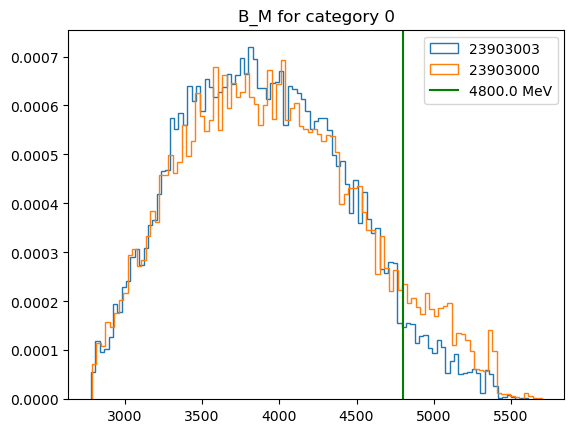

In [33]:
plot_for_category(0, density=True)

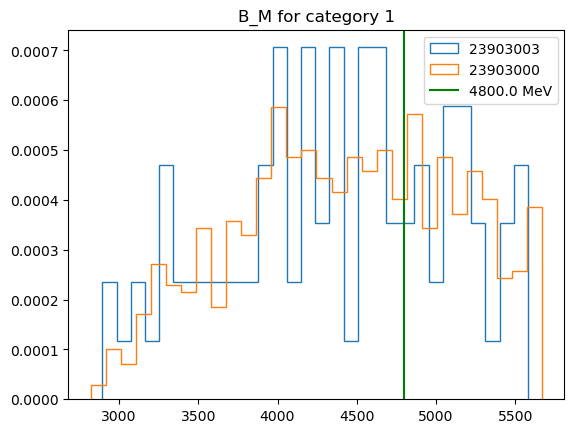

In [34]:
plot_for_category(1, density=True, nbins=30)

/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


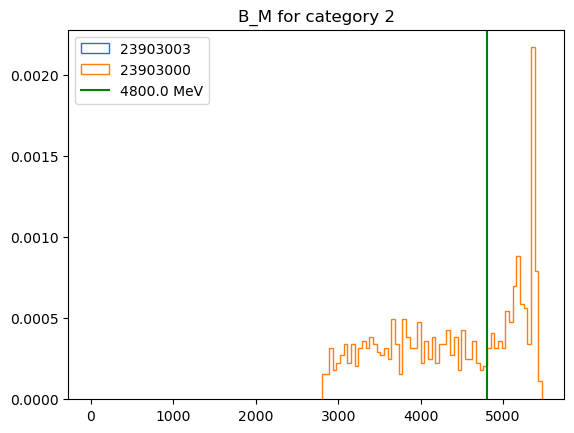

In [35]:
plot_for_category(2, density=True, nbins=60)

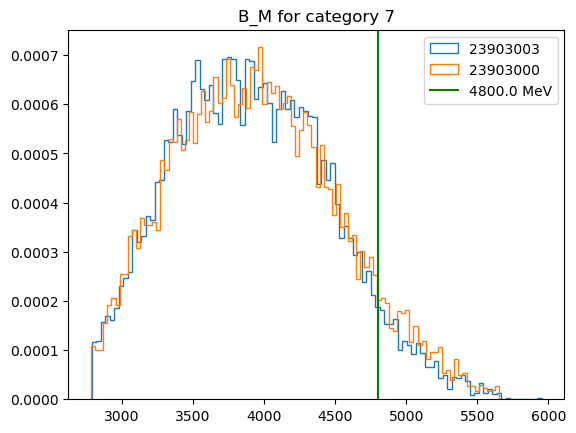

In [36]:
plot_for_category(7, density=True)

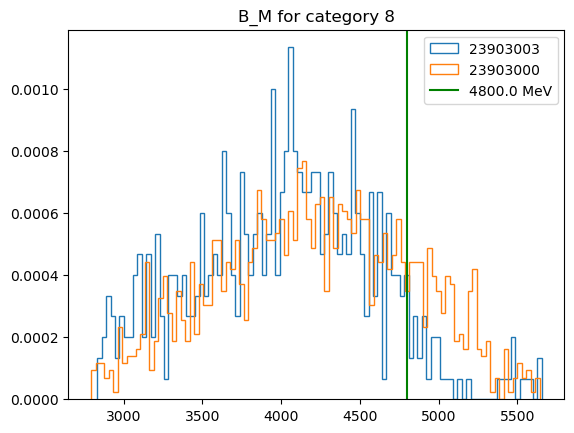

In [37]:
plot_for_category(8, density=True)

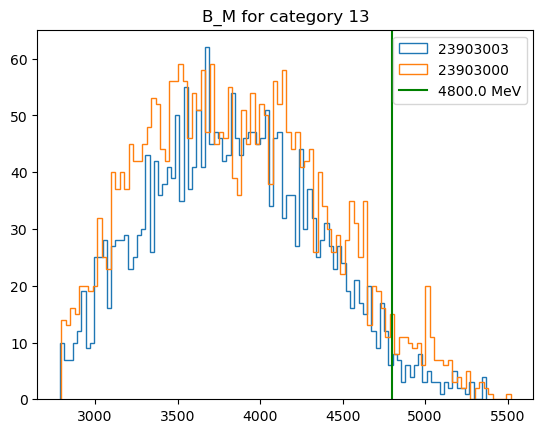

In [38]:
plot_for_category(13, density=False)

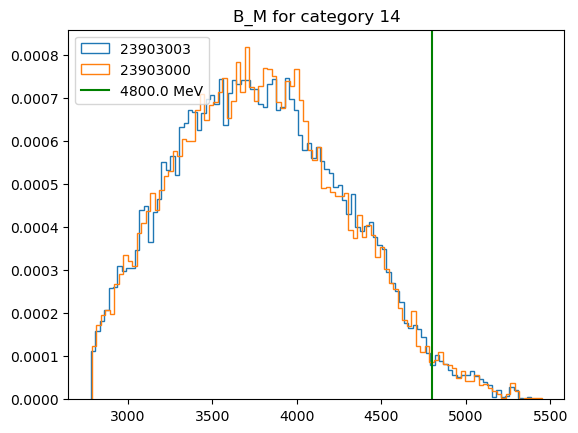

In [39]:
plot_for_category(14, density=True)

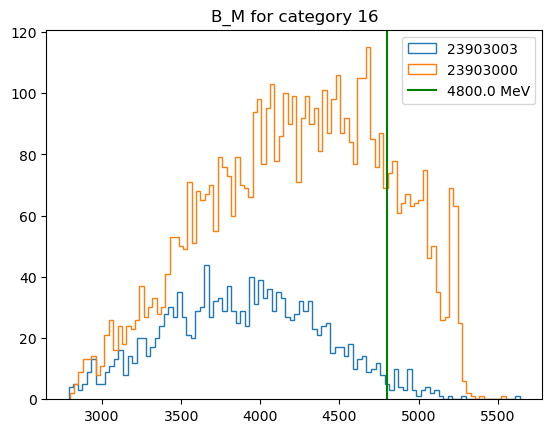

In [40]:
plot_for_category(16, density=False)

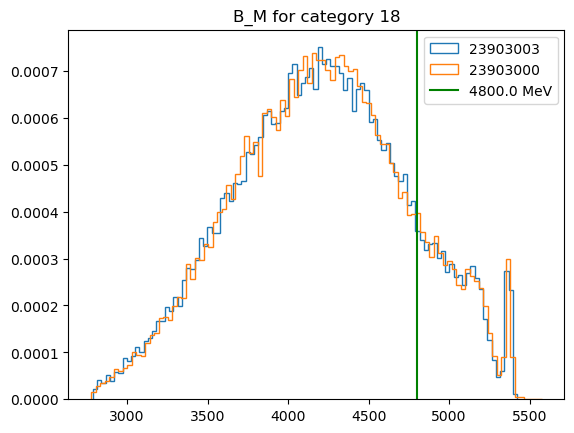

In [41]:
plot_for_category(18, density=True)

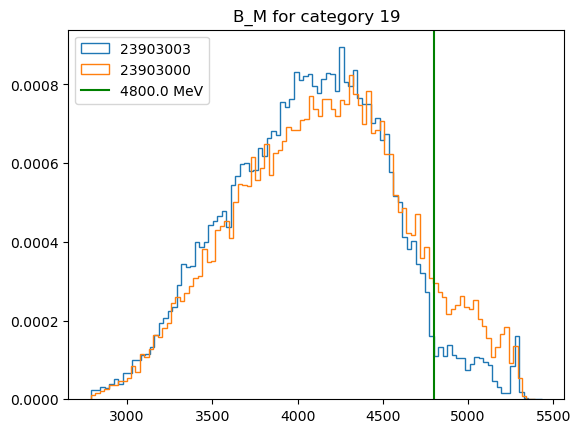

In [42]:
plot_for_category(19, density=True)

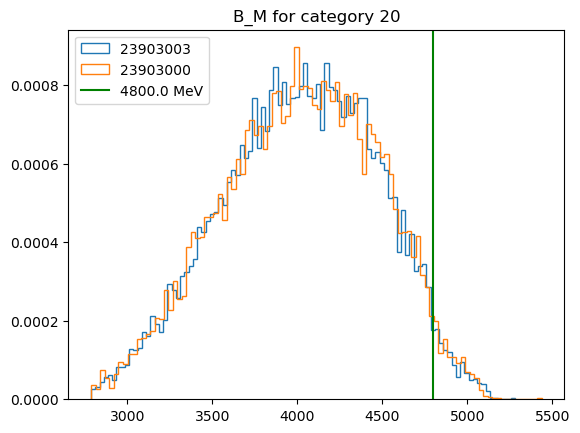

In [43]:
plot_for_category(20, density=True)

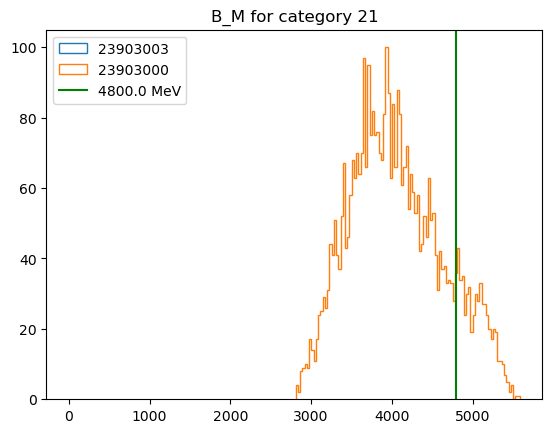

In [44]:
plot_for_category(21, density=False)

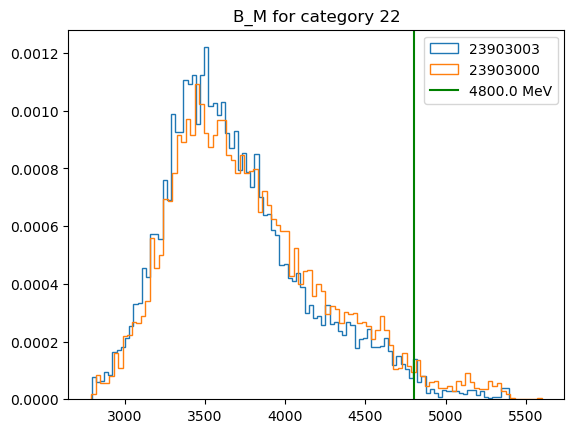

In [45]:
plot_for_category(22)

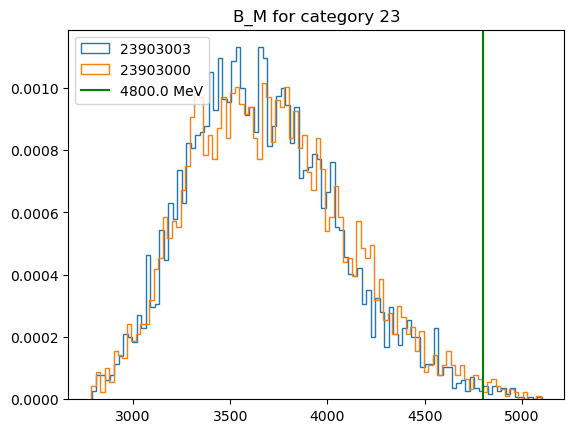

In [46]:
plot_for_category(23)

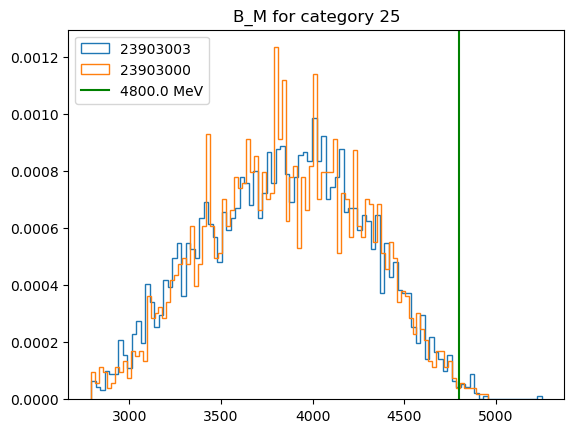

In [47]:
plot_for_category(25)

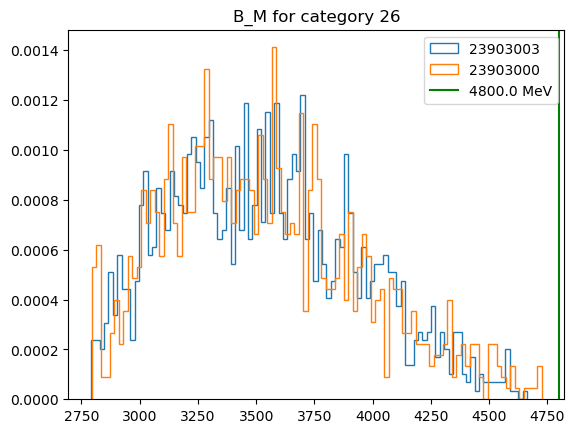

In [48]:
plot_for_category(26)

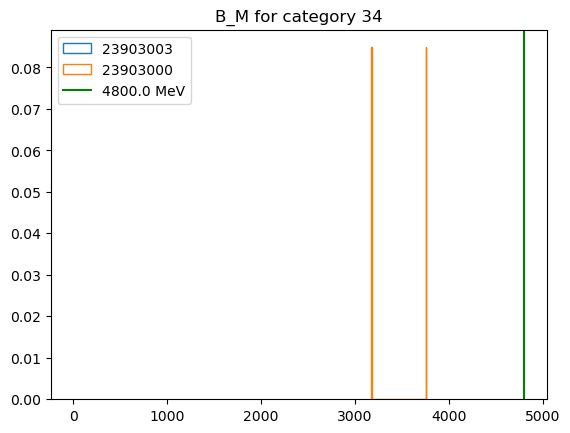

In [49]:
plot_for_category(34)

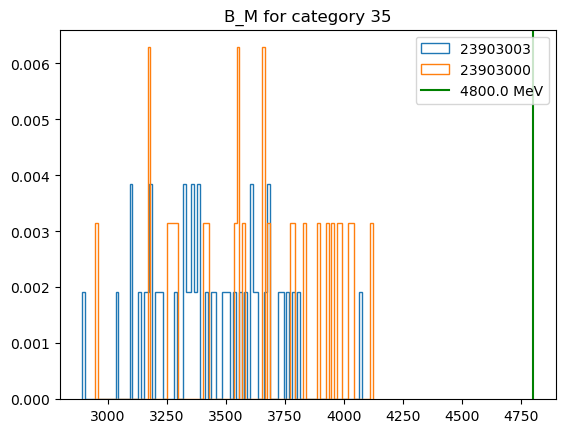

In [50]:
plot_for_category(35)

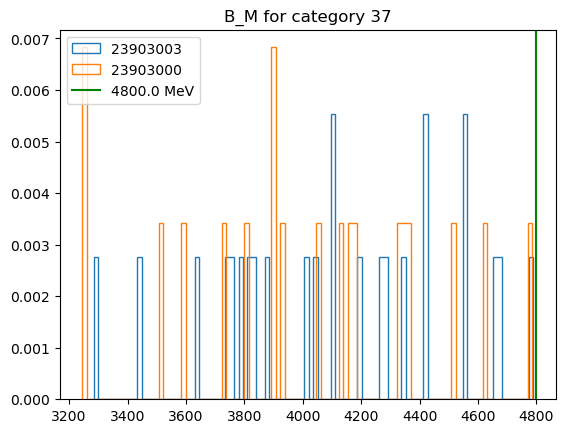

In [51]:
plot_for_category(37)

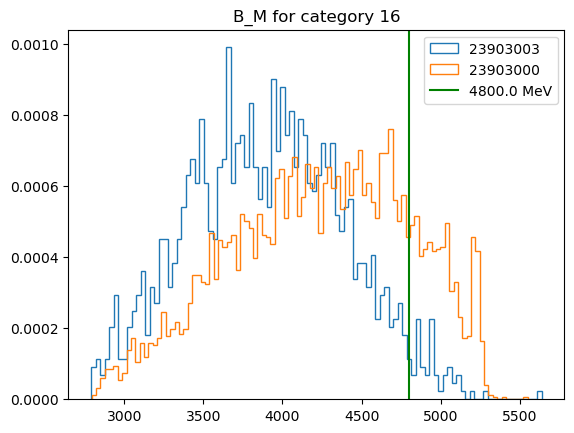

In [101]:
plot_for_category(16, density=True)

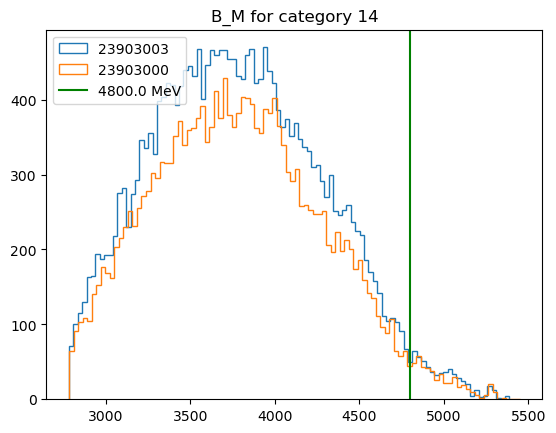

In [53]:
plot_for_category(14, density=False)

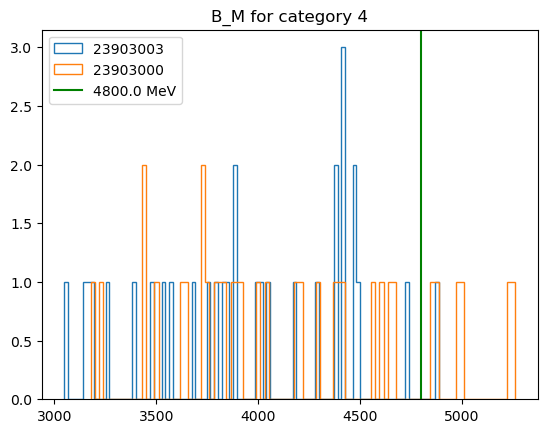

In [54]:
plot_for_category(4, density=False)

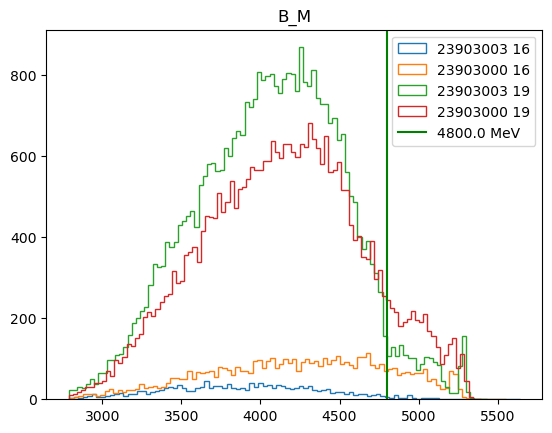

In [55]:
density=False
plt.hist(df23903003[(df23903003.category==16)].B_M, bins=100, histtype='step', label='23903003 16', density=density)
plt.hist(df23903000[(df23903000.category==16)].B_M, bins=100, histtype='step', label='23903000 16', density=density)

plt.hist(df23903003[(df23903003.category==19)].B_M, bins=100, histtype='step', label='23903003 19', density=density)
plt.hist(df23903000[(df23903000.category==19)].B_M, bins=100, histtype='step', label='23903000 19', density=density)

plt.axvline(x = limit, color = 'g', label = f'{limit} MeV')
plt.legend()
plt.title("B_M");

In [56]:
g3 = mygroupby(df23903003[df23903003.B_M > 4800 ], "category")
#g3.plot.pie(y='category', figsize=(5, 5))
g3


,category,count,Percentage,cumulative %
0,18,5913,55.819881,55.819881
1,19,1694,15.991693,71.811574
2,7,732,6.910224,78.721797
3,0,706,6.664779,85.386576
4,14,599,5.654678,91.041254
5,20,504,4.757859,95.799113
6,22,159,1.500991,97.300104
7,13,79,0.745776,98.045879
8,16,52,0.490890,98.536770
9,8,35,0.330407,98.867176


In [57]:
g = mygroupby(df23903000[df23903000.B_M > 4800 ], "category")
#g.plot.pie(y='category', figsize=(5, 5));
g

,category,count,Percentage,cumulative %
0,18,4338,32.040771,32.040771
1,19,3184,23.517246,55.558018
2,0,1275,9.417239,64.975257
3,16,977,7.216190,72.191447
4,7,831,6.137824,78.329271
5,21,548,4.047566,82.376837
6,14,484,3.574858,85.951695
7,2,393,2.902725,88.854421
8,20,357,2.636827,91.491248
9,8,281,2.075486,93.566733


In [58]:
category_map = {
    
        "0": "Xc_background",
        "1": "Xc_signal_Ypis_diffAncestorYXc",
        "2": "Xc_signal_Ypis_B_vertex_fromBs",
        "3": "Xc_signal_Ypis_B_vertex_fromOtherB",
        "4": "Xc_signal_Ypis_B_vertex_fromHc",
        "5": "Xc_signal_Ypis_B_vertex_fromNone",
        "6": "Xc_signal_Ypis_nomatch_Prompt",
        "7": "Xc_signal_Ypis_nomatch_doubleCharm",
        "8": "Xc_signal_Ypis_nomatch_charmStrange",
        "9": "Xc_signal_Ypis_nomatch_Other",
        "10": "Xc_signal_Ypis_diffVertex_signal",
        "11": "Xc_signal_Ypis_diffVertex_tauFromB",
        "12": "Xc_signal_Ypis_diffVertex_normlike",
        "13": "Xc_signal_Ypis_diffVertex_doubleCharm",
        "14": "Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB",
        "15": "Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB",
        "16": "Xc_signal_Ypis_diffVertex_CharmStrange",
        "17": "Xc_signal_Ypis_diffVertex_SomeFromPV",
        "18": "Xc_signal_Ypis_displaced_fromBs_fromDs",
        "19": "Xc_signal_Ypis_displaced_fromB0_fromDp",
        "20": "Xc_signal_Ypis_displaced_fromBp_fromD0",
        "21": "Xc_signal_Ypis_displaced_fromLambdab_fromLambdac",
        "22": "Xc_signal_Ypis_displaced_fromBs_fromDp",
        "23": "Xc_signal_Ypis_displaced_fromBp_fromDp",
        "24": "Xc_signal_Ypis_displaced_fromBs_fromTau",
        "25": "Xc_signal_Ypis_displaced_fromB0_fromD0",
        "26": "Xc_signal_Ypis_displaced_fromB0_fromDs",
        "27": "Xc_signal_Ypis_displaced_fromBs_fromD0",
        "28": "Xc_signal_Ypis_displaced_fromBp_fromDs",
        "29": "Xc_signal_Ypis_displaced_fromBs_fromDs_fromTau",
        "30": "Xc_signal_Ypis_displaced_fromLambdab_fromDs",
        "31": "Xc_signal_Ypis_displaced_fromLambdab_fromDp",
        "32": "Xc_signal_Ypis_displaced_fromXic",
        "33": "Xc_signal_Ypis_displaced_fromBs",
        "34": "Xc_signal_Ypis_displaced_fromB0_fromLambdac",
        "35": "Xc_signal_Ypis_displaced_fromB0_fromDs_fromTau",
        "36": "Xc_signal_Ypis_displaced_fromLambdab_fromD0",
        "37": "Xc_signal_Ypis_displaced_fromB0_fromDp_fromTau",
        "38": "Xc_signal_Ypis_displaced_NA",
        "39": "Xc_signal_Ypis_displaced_fromBp_fromDs_fromTau",
        "40": "Xc_signal_Ypis_displaced_fromBp",
        "41": "Xc_signal_Ypis_displaced_fromLambdab_fromDs_fromTau",
        "42": "Xc_signal_Ypis_displaced_fromBp_fromLambdac",
        "43": "Xc_signal_Ypis_displaced_fromDs",
        "44": "Xc_signal_Ypis_displaced_fromBs_fromDp_fromTau",
        "45": "Xc_signal_Ypis_displaced_fromBp_fromDp_fromTau",
        "46": "Xc_signal_Ypis_displaced_fromBs_fromLambdac",
        "47": "Xc_signal_Ypis_displaced_fromLambdab",
        "48": "Xc_signal_Ypis_displaced_fromB0",
        "49": "Xc_signal_Ypis_displaced_fromLambdac",
        "-1": "NA"
 }

## Checking the repartition of categories in the two Inclusive MC samples

In [59]:
result = pd.merge(g, g3, on="category", how="outer", suffixes=("_23903000", "_23903003"))
result["name"] = result.apply(lambda row: category_map[str(int(row.category))], axis=1)
result[['category', 'name', 'Percentage_23903000', 'Percentage_23903003']]

,category,name,Percentage_23903000,Percentage_23903003
0,18,Xc_signal_Ypis_displaced_fromBs_fromDs,32.040771,55.819881
1,19,Xc_signal_Ypis_displaced_fromB0_fromDp,23.517246,15.991693
2,0,Xc_background,9.417239,6.664779
3,16,Xc_signal_Ypis_diffVertex_CharmStrange,7.216190,0.490890
4,7,Xc_signal_Ypis_nomatch_doubleCharm,6.137824,6.910224
5,21,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,4.047566,NaN
6,14,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,3.574858,5.654678
7,2,Xc_signal_Ypis_B_vertex_fromBs,2.902725,NaN
8,20,Xc_signal_Ypis_displaced_fromBp_fromD0,2.636827,4.757859
9,8,Xc_signal_Ypis_nomatch_charmStrange,2.075486,0.330407


## Checking the Xc_signal_Ypis_diffVertex_CharmStrange

In [60]:
df23903000["p1_fromB0"] = df23903000.apply(lambda row: ("511" in row.p1_fromY_TOP), axis=1)

In [61]:
mygroupby(df23903000[(df23903000.category == 16)&(df23903000.B_M > 4800)], 'p1_fromB0')

,p1_fromB0,count,Percentage,cumulative %
0,True,867,88.741044,88.741044
1,False,110,11.258956,100.000000


In [62]:
mygroupby(df23903000[(df23903000.category == 16)], 'p1_fromB0')

,p1_fromB0,count,Percentage,cumulative %
0,True,3947,71.920554,71.920554
1,False,1541,28.079446,100.000000


In [63]:
df23903000[(df23903000.category == 16)&(df23903000.B_M > 4800)]

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass,HIGH_B_M,p1_fromB0
85,-211:-421:-413:511:513:-5,511:513,0.0,321:-421:-413:511:513:-5,511:513,0.0,-211:-413:511:513:-5,511:513,0.0,5186.021018,16,11.308330,584.957544,1788.312991,146.237938,2015.367433,True,True
346,-211:-413:511:513:-5,511:513,0.0,321:-421:-413:511:513:-5,511:513,0.0,-211:-421:-413:511:513:-5,511:513,0.0,4966.476618,16,11.381556,545.943213,1785.329783,151.595233,1968.173846,True,True
455,13:-421:511:513:-5,511:513,0.0,321:-421:511:513:-5,511:513,0.0,-211:511:513:-5,511:513,0.0,4849.381404,16,11.816361,1077.959274,1338.071900,731.392079,2716.561422,True,True
553,211:413:531:533:-5,531:533,0.0,-321:421:413:531:533:-5,531:533,0.0,211:421:413:531:533:-5,531:533,0.0,5024.389117,16,10.417804,490.919511,1328.435047,279.396388,1585.530709,True,False
672,211:413:-511:-513:5,511:513,0.0,-321:421:413:-511:-513:5,511:513,0.0,211:421:413:-511:-513:5,511:513,0.0,5053.329595,16,11.868986,525.022714,1787.409101,-743.986441,2887.352991,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152259,-211:-413:-511:-513:5,511:513,0.0,321:-421:-413:-511:-513:5,511:513,0.0,-211:-421:-413:-511:-513:5,511:513,0.0,4919.069424,16,11.359930,600.587018,1783.721669,153.650573,1955.415879,True,True
152324,-211:-413:511:515:-5,511:515,0.0,321:-421:-413:511:515:-5,511:515,0.0,-211:-421:-413:511:515:-5,511:515,0.0,5048.199679,16,11.450937,513.107347,1760.477380,126.658769,1933.828328,True,True
152454,211:413:-511:-513:5,511:513,0.0,-321:421:413:-511:-513:5,511:513,0.0,211:421:413:-511:-513:5,511:513,0.0,5122.716272,16,12.806917,561.605248,1746.918723,119.831997,1913.673310,True,True
152707,211:413:511:-5,511,0.0,-321:421:413:511:-5,511,0.0,211:421:413:511:-5,511,0.0,5075.613263,16,11.864090,594.280718,1780.002221,-223.395631,2226.991105,True,True


In [64]:
mygroupby(df23903000[(df23903000.category == 16)&(df23903000.B_M > 4800)], 'p1_fromY_TOP')

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,548,56.090072,56.090072
1,511,191,19.549642,75.639713
2,531:533,48,4.912999,80.552712
3,521:523,23,2.354145,82.906858
4,531,22,2.251791,85.158649
5,511:513:20523,22,2.251791,87.410440
6,511:525,15,1.535312,88.945752
7,511:513:20513,10,1.023541,89.969294
8,521,10,1.023541,90.992835
9,511:513:525,10,1.023541,92.016377


In [65]:
df23903003[(df23903003.category == 16)&(df23903000.B_M > 4800)]

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass,HIGH_B_M
128,211:411:-511:-513:5,511:513,-511.0,-211:310:411:-511:-513:5,511:513,-511.0,211:310:411:-511:-513:5,511:513,-511.0,2947.164061,16,10.032066,470.636741,498.610962,923.241459,890.152356,False
3770,211:421:-521:-515:5,521:515,0.0,-321:421:-521:-515:5,521:515,0.0,-11:22:111:223:421:-521:-515:5,521:515,0.0,4054.248512,16,10.621218,405.660355,590.028025,911.024498,958.432635,False
5892,211:421:-521:-523:-20523:5,521:523:20523,0.0,-211:-213:-10323:421:-521:-523:-20523:5,10323:521:523:20523,0.0,211:310:-311:-10323:421:-521:-523:-20523:5,10323:521:523:20523,0.0,4391.066841,16,10.493390,388.126508,730.306062,716.253959,1301.346166,False
7094,-211:-413:511:-5,511,0.0,321:313:-421:-413:511:-5,511,0.0,-211:223:-421:-413:511:-5,511,0.0,3740.937717,16,12.272943,368.440481,584.104206,943.696374,812.278351,False
9873,-321:-531:-533:5,531:533,0.0,321:-421:-531:-533:5,531:533,0.0,-211:113:-20213:-421:-531:-533:5,20213:531:533,0.0,4501.015663,16,12.514823,293.363269,1229.879637,112.182025,1898.544242,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143405,-211:113:-20213:-421:-413:-511:5,20213:511,0.0,321:-421:-413:-511:5,511,0.0,-211:-413:-511:5,511,0.0,3880.711919,16,11.826168,358.217728,585.755494,808.397025,1221.633550,False
143859,-211:-413:531:533:-5,531:533,0.0,211:310:-311:531:533:-5,531:533,0.0,-211:-421:-413:531:533:-5,531:533,0.0,3730.544732,16,9.933202,417.131837,1119.370313,381.213208,1570.633871,False
148626,-211:-323:-431:-433:-511:-513:5,511:513,0.0,211:310:-311:-323:-431:-433:-511:-513:5,511:513,0.0,-211:310:-311:-323:-431:-433:-511:-513:5,511:513,0.0,3159.616432,16,10.701938,491.170659,640.915617,810.014342,969.958255,False
149413,321:-531:5,531,0.0,-211:223:421:-531:5,531,0.0,211:421:-531:5,531,0.0,3467.721154,16,11.267679,493.837666,1023.667011,517.597514,1415.030581,False


In [66]:
mygroupby(df23903003[(df23903003.category == 16)&(df23903003.B_M > 4800)], 'p1_fromY_TOP')

,p1_fromY_TOP,count,Percentage,cumulative %
0,521:523,19,36.538462,36.538462
1,511:513,12,23.076923,59.615385
2,521,5,9.615385,69.230769
3,511,3,5.769231,75.000000
4,531:533,3,5.769231,80.769231
5,10423:521:523,1,1.923077,82.692308
6,20213:511:513,1,1.923077,84.615385
7,20423:521,1,1.923077,86.538462
8,511:513:515,1,1.923077,88.461538
9,511:525,1,1.923077,90.384615


In [67]:
df23903000[(df23903000.category == 18)&(df23903000.B_M > 4800)]

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass,HIGH_B_M,p1_fromB0
15,-211:-431:-433:531:-5,531,0.0,211:9030221:-431:-433:531:-5,9030221:531,0.0,-211:9030221:-431:-433:531:-5,9030221:531,0.0,4979.930120,18,10.909807,702.527996,1441.928380,191.533652,1991.849004,True,False
73,211:9010221:431:433:531:533:-5,9010221:531:533,0.0,-211:9010221:431:433:531:533:-5,9010221:531:533,0.0,211:431:433:531:533:-5,531:533,0.0,4913.697182,18,10.852650,917.038005,947.927965,173.610714,2034.485809,True,False
104,-211:9010221:-431:-433:531:-5,9010221:531,0.0,211:9010221:-431:-433:531:-5,9010221:531,0.0,-211:-431:-433:531:-5,531,0.0,5082.481481,18,11.236241,1034.014439,1529.367534,172.905573,2046.387059,True,False
128,211:225:431:531:533:-5,531:533,0.0,-211:225:431:531:533:-5,531:533,0.0,211:431:531:533:-5,531:533,0.0,5207.781677,18,11.623002,1165.654587,1476.657432,177.940697,1964.822169,True,False
178,-211:9010221:-431:-433:-531:-533:5,9010221:531:533,0.0,211:9010221:-431:-433:-531:-533:5,9010221:531:533,0.0,-211:-431:-433:-531:-533:5,531:533,0.0,5002.940335,18,11.016002,770.048847,969.813503,169.519971,1983.779936,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152586,211:431:433:531:533:-5,531:533,0.0,-211:113:331:431:433:531:533:-5,531:533,0.0,211:113:331:431:433:531:533:-5,531:533,0.0,5072.257288,18,11.148662,828.440555,1258.156459,103.792919,1895.113215,True,False
152685,-211:-431:531:-5,531,0.0,211:10221:-431:531:-5,10221:531,0.0,-211:10221:-431:531:-5,10221:531,0.0,5434.278793,18,10.178638,1182.884286,1563.111490,193.463143,2052.276667,True,False
152745,-211:-431:-433:-531:-533:5,531:533,0.0,321:-431:-433:-531:-533:5,531:533,0.0,-321:-431:-433:-531:-533:5,531:533,0.0,5049.911682,18,11.683692,721.886491,1465.125206,-221.311338,1941.564969,True,False
152747,211:9010221:431:531:533:-5,9010221:531:533,0.0,-211:9010221:431:531:533:-5,9010221:531:533,0.0,211:431:531:533:-5,531:533,0.0,5320.746564,18,12.147056,967.153393,1009.017080,167.897160,2104.646304,True,False


# Checking the D+

Cat22 Bs_fromDp
Cat23 Bp_fromDp
Cat19 B0_fromDp

look to the normalized variables not only of the B_M but also of log(Y_PE) min_m2pi, max_m2pi, missing_PY_mass

In [68]:
df23903003_19 = df23903003[(df23903003.category==19)]
df23903003_22 = df23903003[(df23903003.category==22)]
df23903003_23 = df23903003[(df23903003.category==23)]
df23903000_19 = df23903000[(df23903000.category==19)]
df23903000_22 = df23903000[(df23903000.category==22)]
df23903000_23 = df23903000[(df23903000.category==23)]

In [69]:
def plot_var(varname, categ, density=True):
        plt.hist(df23903003[(df23903003.category == categ)][varname], bins=100, histtype='step', label=f'23903003', density=density)
        plt.hist(df23903000[(df23903000.category == categ)][varname], bins=100, histtype='step', label=f'23903000', density=density)
        plt.legend()
        plt.title(f"{varname} for categories {categ}")

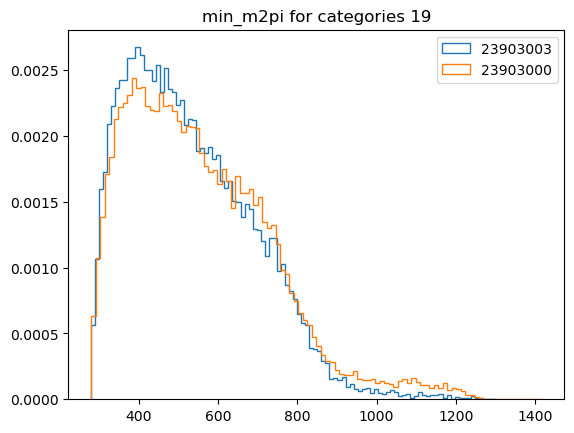

In [70]:
plot_var("min_m2pi", 19)

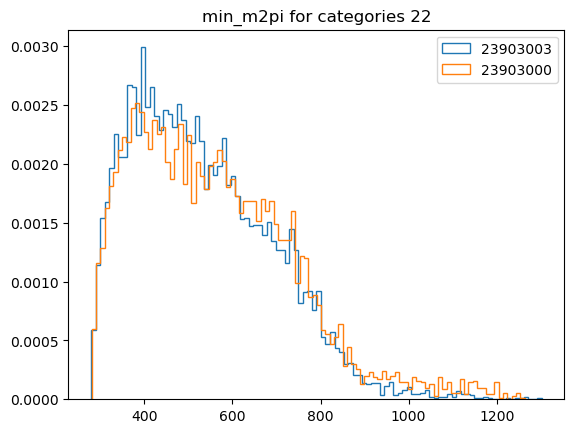

In [71]:
plot_var("min_m2pi", 22)

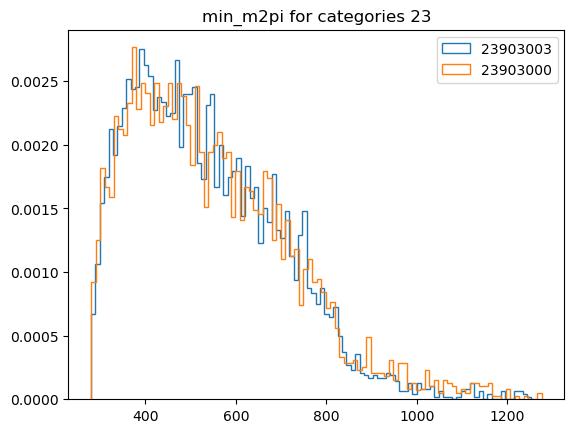

In [72]:
plot_var("min_m2pi", 23)

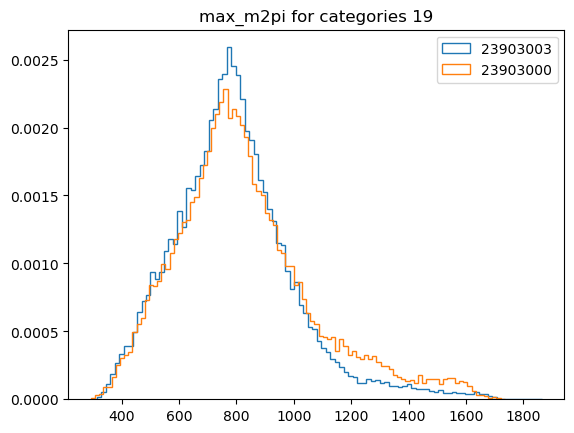

In [73]:
plot_var("max_m2pi", 19)

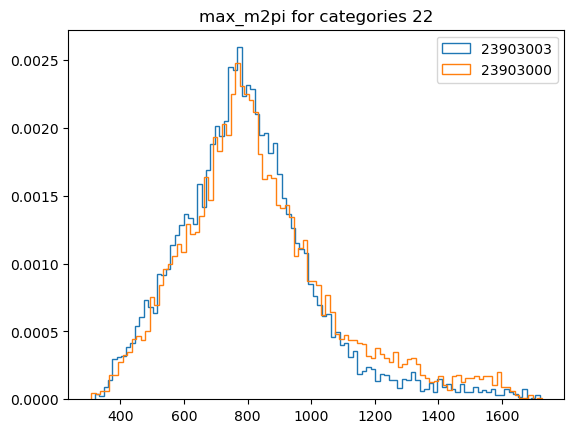

In [74]:
plot_var("max_m2pi", 22)

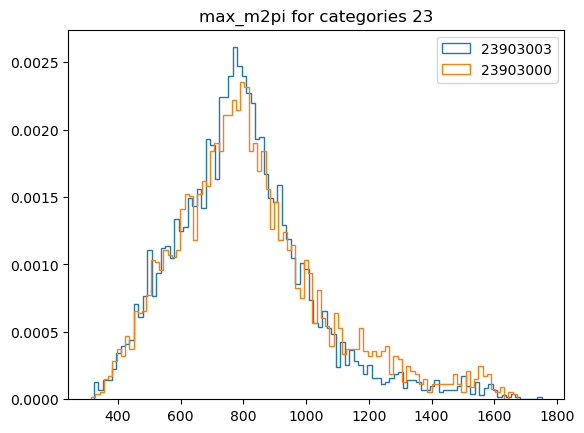

In [75]:
plot_var("max_m2pi", 23)

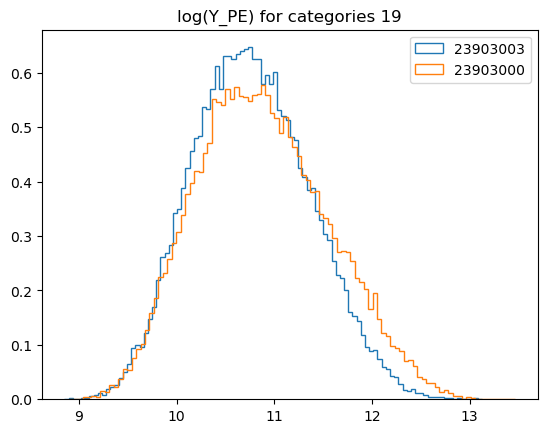

In [76]:
plot_var("log(Y_PE)", 19)

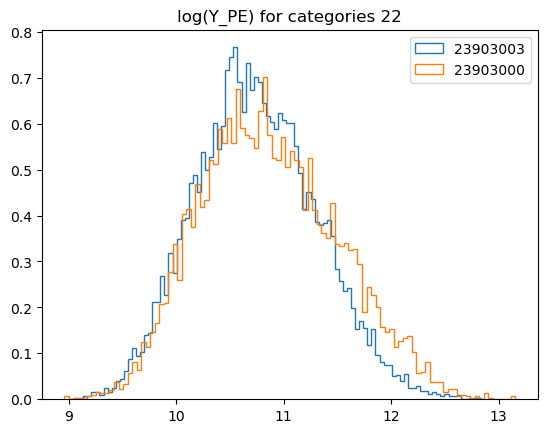

In [77]:
plot_var("log(Y_PE)", 22)

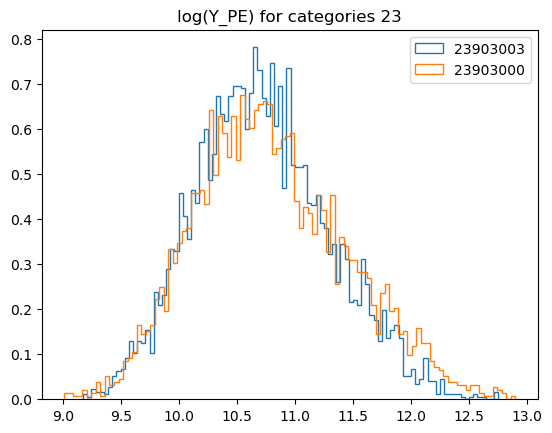

In [78]:
plot_var("log(Y_PE)", 23)

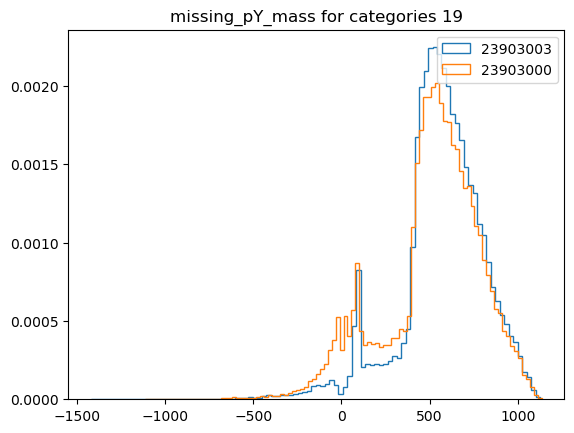

In [79]:
plot_var("missing_pY_mass", 19, density=True)

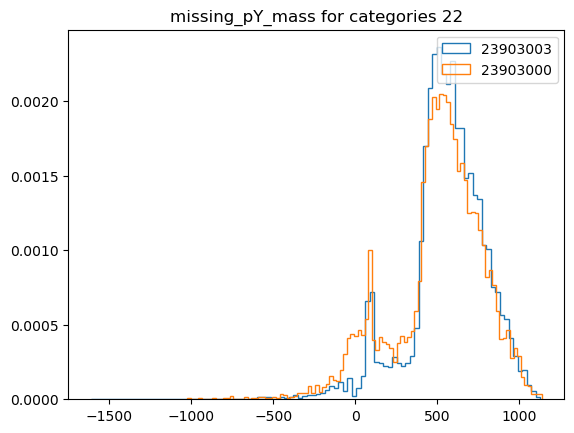

In [80]:
plot_var("missing_pY_mass", 22)

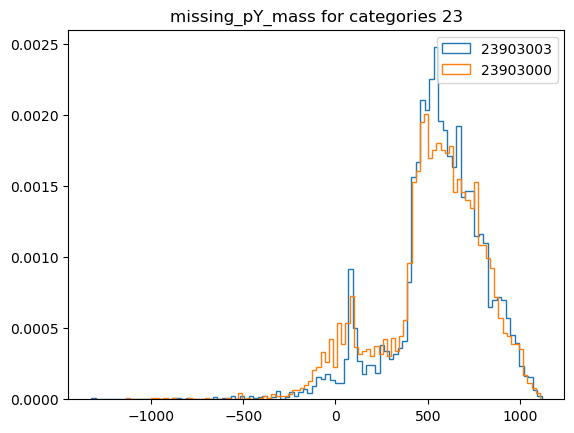

In [81]:
plot_var("missing_pY_mass", 23)

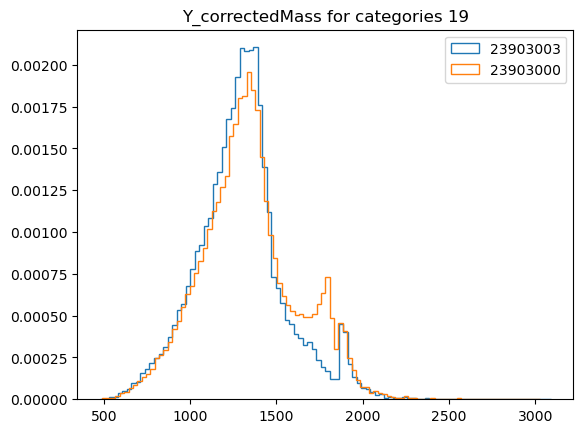

In [82]:
plot_var("Y_correctedMass", 19, density=True)

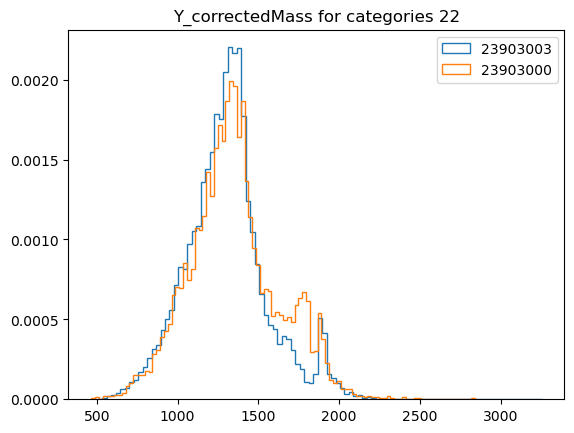

In [83]:
plot_var("Y_correctedMass", 22, density=True)

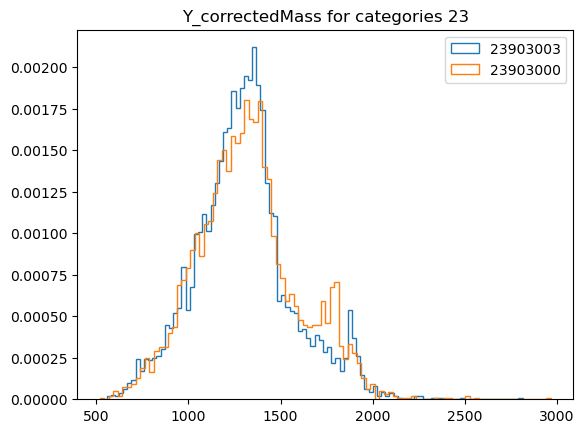

In [84]:
plot_var("Y_correctedMass", 23, density=True)

# Checking the candidates in the range where the Y_correctedMass differs

## For category 19

In [85]:
df23903000[(df23903000.category == 19)&(df23903000.Y_correctedMass > 1600)&(df23903000.Y_correctedMass < 1800)]

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass,HIGH_B_M,p1_fromB0
1,-211:-411:511:513:-5,511:513,511.0,321:-411:511:513:-5,511:513,511.0,-211:-411:511:513:-5,511:513,511.0,4290.554743,19,11.387159,981.135871,1117.291204,-18.277289,1780.966855,False,True
31,211:113:331:411:413:-511:-513:5,511:513,413.0,-211:113:331:411:413:-511:-513:5,511:513,413.0,211:411:413:-511:-513:5,511:513,413.0,4758.008827,19,12.021547,790.791769,1313.452366,37.723796,1764.204453,False,True
60,-211:-411:511:513:5,511:513,511.0,321:-411:511:513:5,511:513,511.0,-211:-411:511:513:5,511:513,511.0,5175.139612,19,11.941663,654.976270,1008.188540,22.311734,1771.949797,True,True
198,-211:-411:511:-5,511,511.0,321:-411:511:-5,511,511.0,-211:-411:511:-5,511,511.0,5183.734368,19,12.691722,487.968221,1027.732184,130.056141,1650.052154,True,True
278,-211:-411:511:513:-5,511:513,511.0,211:-411:511:513:-5,511:513,511.0,-211:-411:511:513:-5,511:513,511.0,4325.040115,19,10.260086,658.570000,784.728927,-148.472056,1796.396423,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152668,211:221:411:511:513:-5,511:513,511.0,-211:221:411:511:513:-5,511:513,511.0,211:411:511:513:-5,511:513,511.0,3755.034487,19,10.327773,401.761754,788.084522,107.886774,1690.537000,False,True
152669,211:221:411:511:513:-5,511:513,511.0,11:111:221:411:511:513:-5,511:513,511.0,211:411:511:513:-5,511:513,511.0,3750.860835,19,10.234963,380.013830,763.289716,116.783672,1700.669088,False,True
152704,-211:-411:511:513:-5,511:513,511.0,321:-411:511:513:-5,511:513,511.0,-211:-411:511:513:-5,511:513,511.0,3913.822939,19,12.053801,835.405187,984.511031,60.372535,1750.548388,False,True
152726,211:411:413:20413:511:513:-5,20413:511:513,413.0,-321:411:413:20413:511:513:-5,20413:511:513,413.0,211:411:413:20413:511:513:-5,20413:511:513,413.0,4108.747011,19,10.990185,638.955205,758.163869,115.423184,1711.632273,False,True


In [86]:
df23903003[(df23903003.category == 19)&(df23903003.Y_correctedMass > 1600)&(df23903003.Y_correctedMass < 1800)]

,p1_fromY_DECAY,p1_fromY_TOP,p1_fromY_Dp_PARENT,p2_fromY_DECAY,p2_fromY_TOP,p2_fromY_Dp_PARENT,p3_fromY_DECAY,p3_fromY_TOP,p3_fromY_Dp_PARENT,B_M,category,log(Y_PE),min_m2pi,max_m2pi,missing_pY_mass,Y_correctedMass,HIGH_B_M
179,211:113:331:411:-511:-513:5,511:513,-511.0,-211:113:331:411:-511:-513:5,511:513,-511.0,211:411:-511:-513:5,511:513,-511.0,4672.895462,19,10.535480,767.342398,1156.079922,117.413663,1689.168173,False
185,211:113:331:411:415:-511:5,511,415.0,-211:113:331:411:415:-511:5,511,415.0,211:411:415:-511:5,511,415.0,4674.187416,19,11.739898,754.105597,1035.109407,-25.453554,1782.071948,False
220,-211:-411:-413:511:513:20523:-5,511:513:20523,-413.0,211:-411:-413:511:513:20523:-5,511:513:20523,-413.0,-211:-411:-413:511:513:20523:-5,511:513:20523,-413.0,4588.513267,19,11.987785,434.693613,1297.293770,235.947863,1625.201188,False
234,-211:113:333:-411:-415:511:513:-5,511:513,-415.0,211:113:333:-411:-415:511:513:-5,511:513,-415.0,-211:-411:-415:511:513:-5,511:513,-415.0,4055.736555,19,11.505251,804.966496,842.369540,172.995219,1654.835563,False
493,211:411:-511:-513:5,511:513,-511.0,-211:411:-511:-513:5,511:513,-511.0,211:411:-511:-513:5,511:513,-511.0,3901.968221,19,10.621545,822.449771,966.642665,100.045500,1748.893550,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170160,-211:-411:-415:511:513:-5,511:513,-415.0,211:-411:-415:511:513:-5,511:513,-415.0,-211:-411:-415:511:513:-5,511:513,-415.0,3631.156014,19,11.253797,345.588588,919.848845,400.815776,1623.322068,False
170213,-211:-411:511:513:-5,511:513,511.0,211:333:-411:511:513:-5,511:513,511.0,-211:333:-411:511:513:-5,511:513,511.0,4935.702179,19,11.528649,597.348167,615.353381,15.733586,1775.851421,True
170217,211:411:-511:-513:5,511:513,-511.0,-211:221:411:-511:-513:5,511:513,-511.0,211:221:411:-511:-513:5,511:513,-511.0,4730.334449,19,11.359967,332.806397,1023.795413,57.380644,1729.090968,False
170511,-211:-411:511:513:-5,511:513,511.0,211:-411:511:513:-5,511:513,511.0,-211:-411:511:513:-5,511:513,511.0,5000.329989,19,11.681585,601.985590,1091.957686,142.736119,1655.037793,True


In [102]:
#mygroupby(df23903000[(df23903000.category == 19)&(df23903000.Y_correctedMass > 1600)&(df23903000.Y_correctedMass < 1800)], "p1_fromY_Dp_PARENT")
mygroupby(df23903000[(df23903000.category == 19)&(df23903000.category == 19)&(df23903000.Y_correctedMass > 1600)], "p1_fromY_Dp_PARENT")

,p1_fromY_Dp_PARENT,count,Percentage,cumulative %
0,511.0,2017,34.884123,34.884123
1,-511.0,1899,32.843307,67.727430
2,413.0,870,15.046697,82.774127
3,-413.0,810,14.008993,96.783120
4,415.0,97,1.677620,98.460740
5,-415.0,89,1.539260,100.000000


In [103]:
mygroupby(df23903003[(df23903003.category == 19)&(df23903003.category == 19)&(df23903003.Y_correctedMass > 1600)], "p1_fromY_Dp_PARENT")

,p1_fromY_Dp_PARENT,count,Percentage,cumulative %
0,-511.0,1341,33.316770,33.316770
1,511.0,1308,32.496894,65.813665
2,-413.0,615,15.279503,81.093168
3,413.0,590,14.658385,95.751553
4,-415.0,87,2.161491,97.913043
5,415.0,84,2.086957,100.000000


## For category 22

p1_fromY_TOP is the list of abs(ancestor_id) with abs(ancestor_id) >= 500 

In [91]:
mygroupby(df23903003[(df23903003.category == 22)&(df23903003.Y_correctedMass > 1600)&(df23903003.Y_correctedMass < 1800)], "p2_fromY_Dp_PARENT")

,p2_fromY_Dp_PARENT,count,Percentage,cumulative %
0,531.0,215,41.828794,41.828794
1,-531.0,214,41.634241,83.463035
2,413.0,45,8.754864,92.217899
3,-413.0,40,7.782101,100.000000


In [92]:
mygroupby(df23903000[(df23903000.category == 22)&(df23903000.Y_correctedMass > 1600)&(df23903000.Y_correctedMass < 1800)], "p2_fromY_Dp_PARENT")

,p2_fromY_Dp_PARENT,count,Percentage,cumulative %
0,531.0,343,43.362832,43.362832
1,-531.0,310,39.190898,82.553729
2,-413.0,80,10.113780,92.667509
3,413.0,58,7.332491,100.000000


## For category 23

In [93]:
mygroupby(df23903003[(df23903003.category == 23)&(df23903003.Y_correctedMass > 1600)&(df23903003.Y_correctedMass < 1800)], "p2_fromY_Dp_PARENT")

,p2_fromY_Dp_PARENT,count,Percentage,cumulative %
0,-521.0,89,26.488095,26.488095
1,521.0,87,25.892857,52.380952
2,425.0,52,15.476190,67.857143
3,-425.0,49,14.583333,82.440476
4,-413.0,32,9.523810,91.964286
5,413.0,27,8.035714,100.000000


In [94]:
mygroupby(df23903000[(df23903000.category == 23)&(df23903000.Y_correctedMass > 1600)&(df23903000.Y_correctedMass < 1800)], "p2_fromY_Dp_PARENT")

,p2_fromY_Dp_PARENT,count,Percentage,cumulative %
0,521.0,143,35.396040,35.396040
1,-521.0,138,34.158416,69.554455
2,425.0,39,9.653465,79.207921
3,413.0,34,8.415842,87.623762
4,-425.0,32,7.920792,95.544554
5,-413.0,18,4.455446,100.000000
